# Tarea Semanal 2: Algoritmo para calcular la DFT
**Autor:** Marco Trabattoni  
**Cátedra:** Procesamiento Digital de Señales - R6051  
**Docente:** Mariano Llamedo Soria
 
---
## 1. Introducción y Configuración
Se pide desarrollar un algoritmo que calcule la transformada discreta de Fourier (DFT).

$$X_k = \sum_{n=0}^{N-1} x_n \cdot e^{-j 2\pi \cdot k \cdot n / N}$$
    
XX = mi_funcion_DFT( xx )

xx: señal a analizar, una matriz (Nx1) de números reales.

XX: DFT de xx, una matriz (Nx1) de números complejos.

En esta sección se importan las librerías necesarias (`numpy` y `matplotlib.pyplot`) y se definen los parámetros globales de la simulación, y las funciones a utilizar durante la misma.

In [17]:
# Importación de módulos que utilizaremos en esta tarea semanal 2:
# Una vez invocadas estas funciones, podremos utilizar los módulos a través 
# del identificador que indicamos luego de "as". 
import numpy as np
import matplotlib.pyplot as plt

#%% PARÁMETROS DE LA SEÑAL SENOIDAL
fs = 1000          # Frecuencia de muestreo (Hz)
N = 1000           # Número de muestras
f0 = 10            # Frecuencia de la senoidal (Hz)

## 2. Definición de Funciones
A continuación, se definen las funciones para generar una señal **Senoidal**, y calcular la **DFT**. `MT_Senoidal` devuelve un vector de tiempo `tt` y un vector de amplitud `xx` de dimensiones $N \times 1$, mientras que la `mi_funcion_DFT` devuelve una matriz de números complejos `XX` de dimensiones $N \times 1$.

In [18]:
#%%  ALGORITMO DFT
def mi_funcion_DFT(xx):
    N = len(xx)
    n = np.arange(N)
    k = n.reshape((N, 1))
    
    matriz_exponencial = np.exp(-2j * np.pi * k * n / N)
    
    XX = np.dot(matriz_exponencial, xx)
    
    return XX

#%%  Definicion de mi señal senoidal (TS1)

def MT_Senoidal(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=100):
    
    """
    Genera una señal senoidal con los siguientes argumentos:
        
    vmax -- Amplitud máxima (Volts)
    dc   -- Valor medio (Volts)
    ff   -- Frecuencia de la senoidal (Hz)
    ph   -- Fase (Radianes)
    nn   -- Cantidad de muestras (#)
    fs   -- Frecuencia de muestreo (Hz)
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    
    # Calculamos el intervalo entre muestras (periodo de muestreo)
    ts = 1/fs
    
    # Generamos el vector de tiempo tt
    tt = np.arange(0.0, N*ts, ts)
    
    # Generamos el vector de señal xx
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx

## 3. Generación y Visualización de análisis 
Se procede a instanciar la senoidal y analizar su DFT, utilizando las funciones definidas anteriormente, para luego graficarlas y verificar su correcto funcionamiento en el dominio del tiempo y frecuencia. 


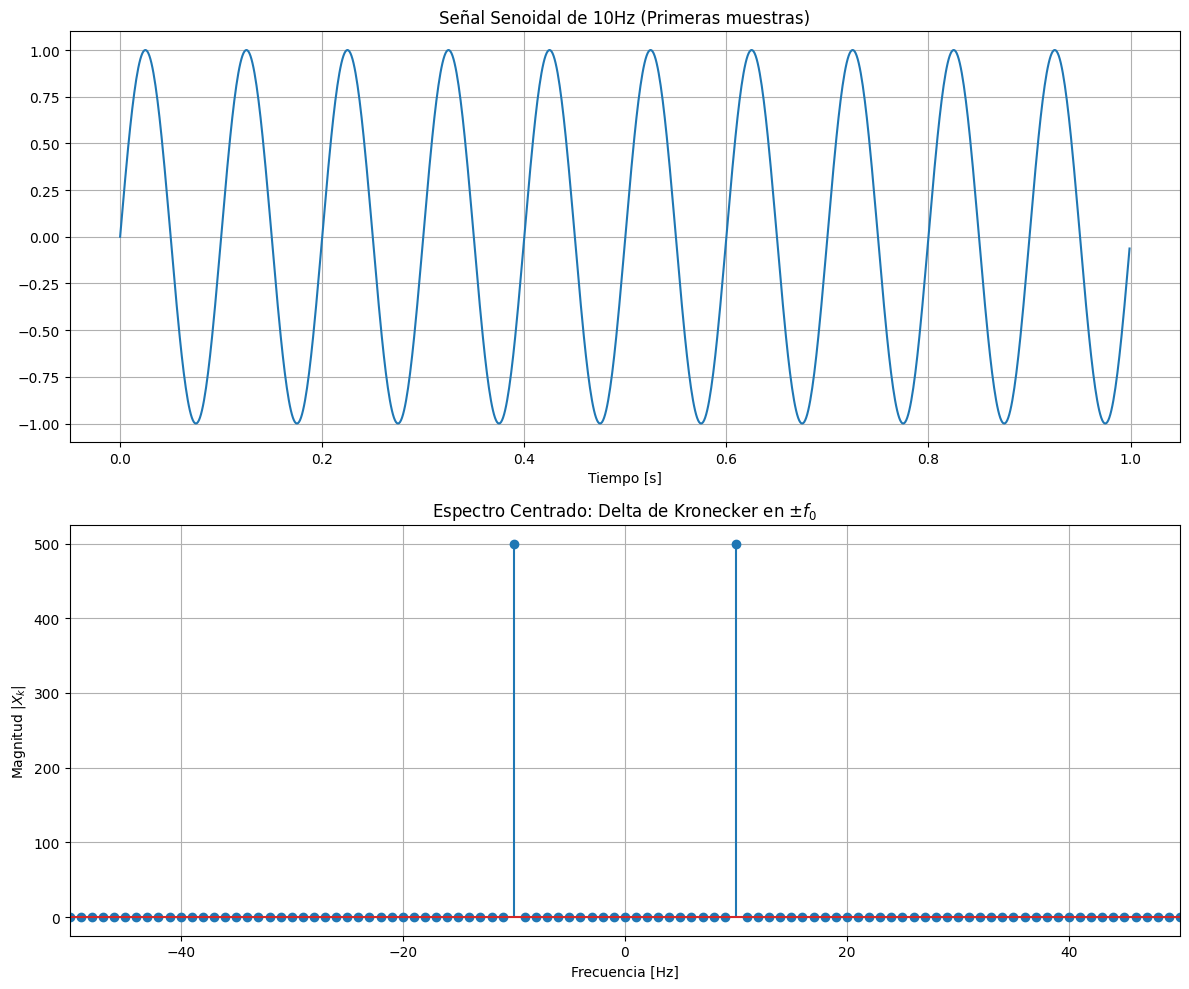

In [19]:
#%% GENERACION DE LA SENOIDAL
tt, xx = MT_Senoidal(vmax=1, dc=0, ff=f0, ph=0, nn=N, fs=fs)

#%% CÁLCULO DE LA DFT
XX = mi_funcion_DFT(xx)
#%% CÁLCULO DE LA FFT
XX = np.fft.fftshift(XX)
frec = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))

#%% GRAFICOS
# Senoidal
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(tt, xx)
plt.title(f"Señal Senoidal de {f0}Hz (Primeras muestras)")
plt.xlabel("Tiempo [s]")
plt.grid(True)

# Espectro de la senoidal (Deltas de Kronecker)
plt.subplot(2, 1, 2)
plt.stem(frec, np.abs(XX))
plt.title("Espectro Centrado: Delta de Kronecker en $\pm f_0$")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud $|X_k|$")
plt.xlim(-50, 50) # Zoom para ver bien las deltas
plt.grid(True)

plt.tight_layout()
plt.show()

Se corrobora que para una ventana de simulación con $N = 1000$ y $f_s = 1000\text{ Hz}$, la duración total del registro es de exactamente $1\text{ segundo}$, conteniendo 10 ciclos completos de la señal de $10\text{ Hz}$.

Al aplicar `np.fft.fftshift`, el espectro se centra correctamente respecto a la frecuencia de continua ($0\text{ Hz}$). Se observa de manera nítida la aparición de dos deltas de Kronecker discretas localizadas en las frecuencias correspondientes a $\pm 10\text{ Hz}$.

Fuera de los $10\text{ Hz}$, la magnitud espectral decae a valores nulos. Esto demuestra experimentalmente la ortogonalidad de la base compleja de Fourier frente a la senoidal bajo estudio y la ausencia de leakage, dado que $f_0$ coincide con un bin del sistema de muestreo.

## 4. Bonus
En esta sección se repiten las mismas experiencias con la transformada rápida de Fourier (DFT rápida se llama FFT) y se calcula la DFT de una señal aleatoria, de ruido uniforme con varianza `σ² = 4`, e incorrelacionado en el dominio de la frecuencia.

Se analiza el comportamiento de la señal en un rango dinámico de amplitudes contenido en el intervalo $[-L/2, L/2]$ con $L = \sqrt{48}$. 

El objetivo es verificar de manera experimental la hipótesis de densidad espectral constante para procesos de tipo ruido blanco.

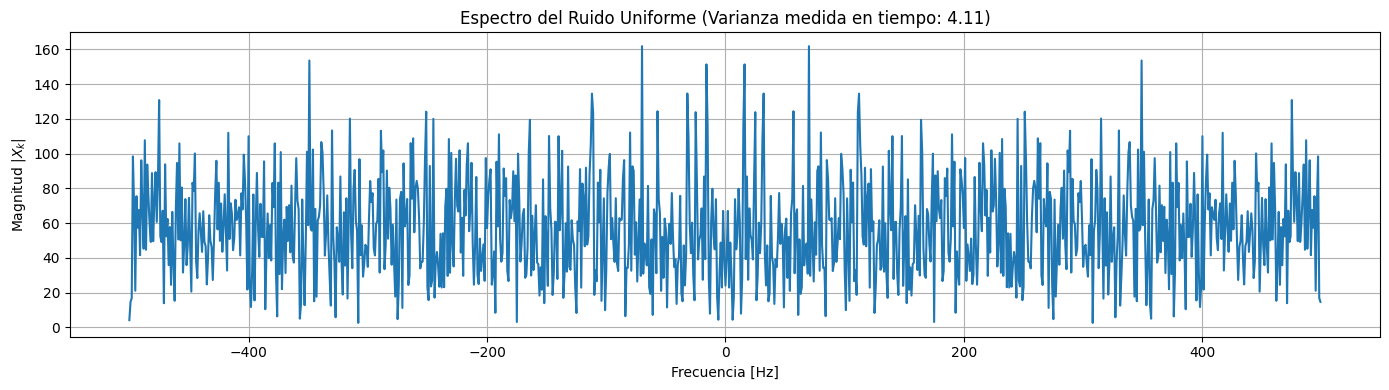

In [20]:
#%% BONUS
L = np.sqrt(48)
xx_ruidosa_temporal = np.random.uniform(-L/2, L/2, N)
XX_ruido_espectro = np.fft.fftshift(mi_funcion_DFT(xx_ruidosa_temporal))

#%% GRAFICO
# Espectro del Ruido Uniforme
plt.figure(figsize=(14, 4))
plt.plot(frec, np.abs(XX_ruido_espectro))
plt.title(f"Espectro del Ruido Uniforme (Varianza medida en tiempo: {np.var(xx_ruidosa_temporal):.2f})")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud $|X_k|$")
plt.grid(True)

plt.tight_layout()
plt.show()

A diferencia de la señal senoidal (donde la energía se concentra en componentes discretas), el espectro del ruido uniforme distribuye su energía de manera equitativa a lo largo de toda la banda de frecuencias (desde $-f_s/2$ hasta $f_s/2$). 

El gráfico muestra un espectro plano en valor medio, acompañado de fluctuaciones aleatorias en cada bin. Esto valida de forma práctica la definición de ruido blanco, cuya densidad espectral de potencia es constante para todo el espectro.

Por otro lado, al calcular de manera matemática la varianza temporal de la muestra generada mediante `np.var(xx_ruidosa_temporal)`, se observa una convergencia hacia el valor teórico de $\sigma^2 = 4.00$, confirmando el proceso aleatorio a partir de los límites calculados analíticamente.

## 5. Conclusiones Generales

La implementación del algoritmo `mi_funcion_DFT` cumplió con las expectativas de diseño. Sometido a señales determinísticas (senoidal pura) y estocásticas (ruido blanco uniforme), resolvió de manera exacta las componentes en frecuencia, demostrando la consistencia física y matemática de la ecuación analítica de la DFT trasladada al código.

El trabajo permitió contrastar de forma directa cómo se manifiesta la energía en el dominio de la frecuencia según la naturaleza de la señal de entrada. 

Mientras que una señal periódica pura concentra toda su potencia en componentes discretas bien localizadas (máxima correlación), un proceso puramente aleatorio e incorrelacionado dispersa su energía de forma uniforme a lo largo de todo el espectro, confirmando experimentalmente el comportamiento teórico del ruido blanco.